In [14]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

## Lab 2: Image Stitching with Homographies

In this lab, we will explore image stitching and panorama creation. You will use a homography to register two images together, and implement bilinear interpolation to help accomplish this. As part of the lab, you will also explore image enhancement strategies to improve the quality of image stitching at the seam (the join between two images) relying on your knowledge of image brightness and human perception of this. Collectively, tasks 1-5 will provide a final stitched image. In task 6, you will apply the same code written in tasks 1-5 to create a panorama image using your own photos.

* Task 1: Draw test points on the left image
* Task 2: Use a homography to find the location of these points in the right image
* Task 3: Bilinear interpolation of the right image pixels
* Task 4: Image stitching 
* Task 5: Better blending
* Task 6: Now try your own!

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

# Task 1: Draw test points on the left image

Draw the following points on the left image as red crosses. Display the resulting image.

{446 , 499, 1}, {383, 590, 1}, {296 , 499, 1}, {282, 511, 1}, {401 , 508, 1}

Recall from lectures that these 3-element homogeneous coordinates can be transformed to 2D image pixel coordinates by dividing the first and second elements by the third (needed for later tasks).

In [15]:
# Load the left and right images
left = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE)
right = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE)

# Convert to display format
left_display = cv2.cvtColor(left, cv2.COLOR_GRAY2BGR)

# Define test points in homogeneous coordinates
test_points_homo = np.array([
    [446, 499, 1],
    [383, 590, 1],
    [296, 499, 1],
    [282, 511, 1],
    [401, 508, 1]
], dtype=np.float32)

# Convert homogeneous coordinates to 2D image pixel coordinates
test_points_2d = test_points_homo[:, :2] / test_points_homo[:, 2:3]

# Draw red crosses on the left image
cross_size = 10
cross_thickness = 2
for point in test_points_2d:
    x, y = int(point[0]), int(point[1])
    # Draw horizontal line
    cv2.line(left_display, (x - cross_size, y), (x + cross_size, y), (0, 0, 255), cross_thickness)
    # Draw vertical line
    cv2.line(left_display, (x, y - cross_size), (x, y + cross_size), (0, 0, 255), cross_thickness)

print("Test points in homogeneous coordinates:")
print(test_points_homo)
print("\nTest points in 2D image coordinates:")
print(test_points_2d)

Test points in homogeneous coordinates:
[[446. 499.   1.]
 [383. 590.   1.]
 [296. 499.   1.]
 [282. 511.   1.]
 [401. 508.   1.]]

Test points in 2D image coordinates:
[[446. 499.]
 [383. 590.]
 [296. 499.]
 [282. 511.]
 [401. 508.]]


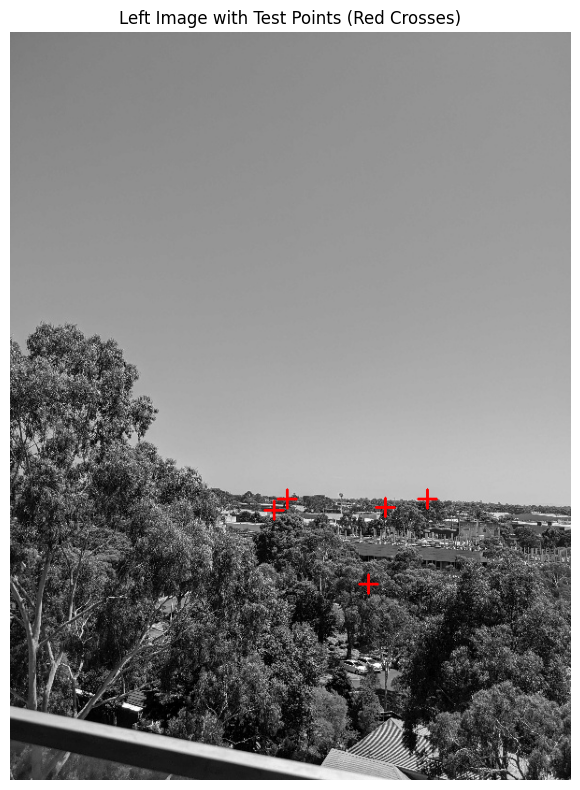

In [16]:
# Display the left image with test points
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(left_display, cv2.COLOR_BGR2RGB))
plt.title('Left Image with Test Points (Red Crosses)')
plt.axis('off')
plt.tight_layout()
plt.show()

# Task 2: Use Homography to find right image points


The following homography transforms pixel coordinates between the left and right images as
$$ x_R = H x_L $$

\begin{bmatrix}
1.6011 & 0.0277 & -393.5701 \\
0.3242 & 1.5119 & -228.8918 \\
0.0009 & 0.0002 & 1.0000
\end{bmatrix}

Apply the homography to transform the left image points in Task 1 to their corresponding locations in the right image. Draw the transformed points as red crosses on the right image. Check your result before moving on.


In [17]:
# Define the homography matrix H
H = np.array([
    [1.6011, 0.0277, -393.5701],
    [0.3242, 1.5119, -228.8918],
    [0.0009, 0.0002, 1.0000]
], dtype=np.float32)

# Transform the test points using the homography: x_R = H @ x_L
# Convert 2D points to homogeneous coordinates for transformation
test_points_homo_transformed = (H @ test_points_homo.T).T

# Convert transformed homogeneous coordinates back to 2D
test_points_transformed_2d = test_points_homo_transformed[:, :2] / test_points_homo_transformed[:, 2:3]

print("Transformed points in homogeneous coordinates:")
print(test_points_homo_transformed)
print("\nTransformed points in 2D image coordinates:")
print(test_points_transformed_2d)

Transformed points in homogeneous coordinates:
[[334.3428   670.13947    1.5012  ]
 [235.99423  787.2978     1.4627  ]
 [ 94.177795 621.5095     1.3662  ]
 [ 72.09479  635.11346    1.356   ]
 [262.54257  669.1576     1.4625  ]]

Transformed points in 2D image coordinates:
[[222.71704  446.40253 ]
 [161.3415   538.2497  ]
 [ 68.93412  454.91843 ]
 [ 53.167248 468.37277 ]
 [179.5163   457.54367 ]]


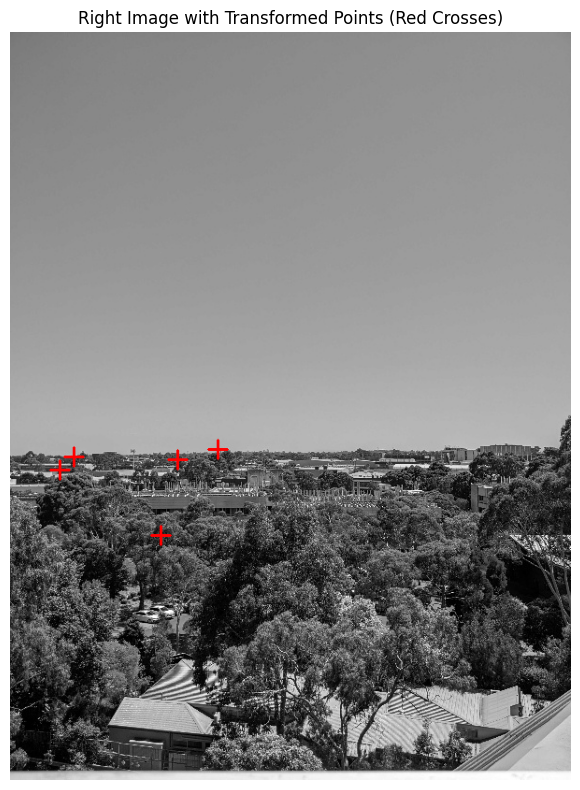


Homography matrix H:
[[ 1.601100e+00  2.770000e-02 -3.935701e+02]
 [ 3.242000e-01  1.511900e+00 -2.288918e+02]
 [ 9.000000e-04  2.000000e-04  1.000000e+00]]


In [18]:
# Convert right image to display format and draw transformed points
right_display = cv2.cvtColor(right, cv2.COLOR_GRAY2BGR)

# Draw red crosses on the right image at transformed locations
for i, point in enumerate(test_points_transformed_2d):
    x, y = int(point[0]), int(point[1])
    if 0 <= x < right.shape[1] and 0 <= y < right.shape[0]:
        # Draw horizontal line
        cv2.line(right_display, (x - cross_size, y), (x + cross_size, y), (0, 0, 255), cross_thickness)
        # Draw vertical line
        cv2.line(right_display, (x, y - cross_size), (x, y + cross_size), (0, 0, 255), cross_thickness)

# Display the right image with transformed points
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(right_display, cv2.COLOR_BGR2RGB))
plt.title('Right Image with Transformed Points (Red Crosses)')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\nHomography matrix H:")
print(H)

# Task 3: Bilinear interpolation of the right image

The transformed coordinates can be in between pixel locations. Write a bilinear interpolation function to compute the intensity of the transformed pixel coordinate in right.jpg using intensity values from neighbouring pixel locations. Print the interpolated intensity value for each transformed point in Task 2. The first point should be around 176 whereas the last point should be around 73.

HINT: The bilinear interpolation function should take the transformed pixel coordinate and the intensity values of its four neighbours as input arguments, and should output the interpolated intensity value.

In [19]:
def bilinear_interpolation(x, y, I_tl, I_tr, I_bl, I_br):
    """
    Perform bilinear interpolation at position (x, y).
    
    Args:
        x, y: Continuous coordinates within [0, 1]
        I_tl: Intensity at top-left corner
        I_tr: Intensity at top-right corner
        I_bl: Intensity at bottom-left corner
        I_br: Intensity at bottom-right corner
    
    Returns:
        Interpolated intensity value
    """
    # Bilinear interpolation formula:
    # I(x,y) = (1-x)(1-y)*I_tl + x(1-y)*I_tr + (1-x)y*I_bl + x*y*I_br
    
    one_minus_x = 1 - x
    one_minus_y = 1 - y
    
    interpolated = (one_minus_x * one_minus_y * I_tl +
                   x * one_minus_y * I_tr +
                   one_minus_x * y * I_bl +
                   x * y * I_br)
    
    return interpolated


def get_pixel_bilinear(image, x, y):
    """
    Get interpolated pixel value at continuous coordinates (x, y) in the image.
    
    Args:
        image: Input image (grayscale)
        x, y: Continuous coordinates
    
    Returns:
        Interpolated intensity value, or None if out of bounds
    """
    # Get the integer and fractional parts
    x_int, y_int = int(x), int(y)
    x_frac, y_frac = x - x_int, y - y_int
    
    height, width = image.shape
    
    # Check if we're close enough to the boundary for interpolation
    if x_int < 0 or x_int >= width - 1 or y_int < 0 or y_int >= height - 1:
        return None
    
    # Get the four neighbor pixels
    I_tl = float(image[y_int, x_int])
    I_tr = float(image[y_int, x_int + 1])
    I_bl = float(image[y_int + 1, x_int])
    I_br = float(image[y_int + 1, x_int + 1])
    
    # Perform bilinear interpolation
    interpolated_value = bilinear_interpolation(x_frac, y_frac, I_tl, I_tr, I_bl, I_br)
    
    return interpolated_value

In [20]:
# Apply bilinear interpolation to each transformed point
print("Interpolated intensity values at transformed points:")
print("Point | Transformed Coordinates | Interpolated Intensity")
print("-" * 60)

interpolated_values = []
for i, point in enumerate(test_points_transformed_2d):
    x, y = point[0], point[1]
    intensity = get_pixel_bilinear(right, x, y)
    
    if intensity is not None:
        interpolated_values.append(intensity)
        print(f"{i+1:5d} | ({x:7.2f}, {y:7.2f})      | {intensity:7.2f}")
    else:
        print(f"{i+1:5d} | ({x:7.2f}, {y:7.2f})      | Out of bounds")

print("\n" + "="*60)
print(f"First point interpolated intensity: {interpolated_values[0]:.2f} (expected ~176)")
print(f"Last point interpolated intensity:  {interpolated_values[-1]:.2f} (expected ~73)")

Interpolated intensity values at transformed points:
Point | Transformed Coordinates | Interpolated Intensity
------------------------------------------------------------
    1 | ( 222.72,  446.40)      |  176.00
    2 | ( 161.34,  538.25)      |   38.47
    3 | (  68.93,  454.92)      |   69.83
    4 | (  53.17,  468.37)      |   58.19
    5 | ( 179.52,  457.54)      |   74.51

First point interpolated intensity: 176.00 (expected ~176)
Last point interpolated intensity:  74.51 (expected ~73)


# Task 4: Image stitching

Create a 1200x800 (width x height) image and fill the left hand side of this image with the left image. This stitched image will use the left image coordinate system (xl) throughout the stitching process. Next, fill in the remaining pixels on the RHS by transforming their pixel coordinates (left image coordinates) to the right image coordinates via the homography from Task 2 and determining the intensity using your bilinear interpolation implementation. If the right pixel  coordinate is valid, generate the pixel value using bilinear interpolation, but if the right pixel coordinate is invalid, use a pixel value of zero. Display the stitching results. It should look like a wide-angle image with a visible seam where the two images join.

In [21]:
# Get image dimensions
left_height, left_width = left.shape
right_height, right_width = right.shape

print(f"Left image size: {left_width} x {left_height}")
print(f"Right image size: {right_width} x {right_height}")

# Create the stitched image canvas (width x height)
canvas_width, canvas_height = 1200, 800
stitched = np.zeros((canvas_height, canvas_width), dtype=np.uint8)

# Fill the left side with the left image
# The left image should be placed at the beginning of the canvas
stitched[:left_height, :left_width] = left

# For the right side, use the homography to transform coordinates and sample from right image
# We need to compute the inverse homography to go from left image coordinates to right image coordinates
H_inv = np.linalg.inv(H)

print(f"\nInverse Homography matrix H_inv:")
print(H_inv)

# Fill the remaining pixels on the RHS using the homography
# For each pixel in the canvas that's beyond the left image, we need to:
# 1. Get its coordinates in the left image space (which is already in left space)
# 2. Transform to right image space using H_inv
# 3. Sample from right image using bilinear interpolation

# Strategy: For pixels in the overlapping region and to the right,
# transform their left-image coordinates to right-image coordinates
print("\nFilling canvas with right image using homography...")

# For efficiency, we'll process the entire right region
for y in range(canvas_height):
    for x in range(left_width, canvas_width):
        # Current pixel is in left image coordinate space
        # Transform to right image coordinate space
        point_homo = np.array([x, y, 1], dtype=np.float32)
        transformed_point = H_inv @ point_homo
        
        # Normalize by the third component (homogeneous coordinates)
        x_right = transformed_point[0] / transformed_point[2]
        y_right = transformed_point[1] / transformed_point[2]
        
        # Sample from right image using bilinear interpolation
        intensity = get_pixel_bilinear(right, x_right, y_right)
        
        if intensity is not None:
            stitched[y, x] = int(np.clip(intensity, 0, 255))
        else:
            # Out of bounds: set to 0 (black)
            stitched[y, x] = 0

print("Stitching complete!")

Left image size: 600 x 800
Right image size: 600 x 800

Inverse Homography matrix H_inv:
[[ 5.2107978e-01 -3.5597976e-02  1.9693335e+02]
 [-1.7736517e-01  6.5409791e-01  7.9912025e+01]
 [-4.3349879e-04 -9.8781406e-05  8.0677760e-01]]

Filling canvas with right image using homography...
Stitching complete!


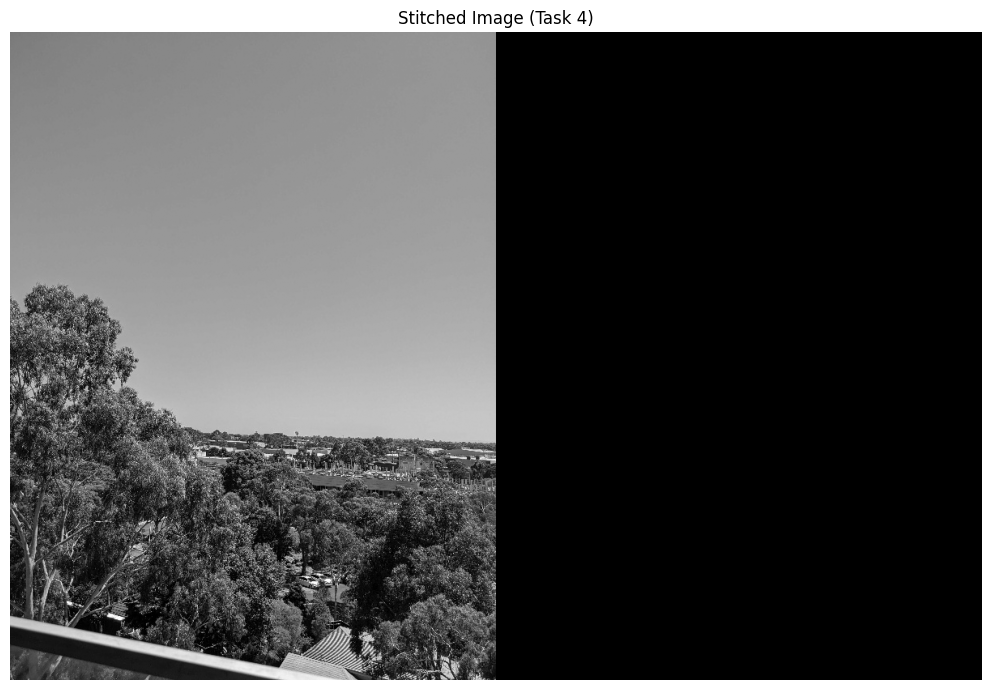

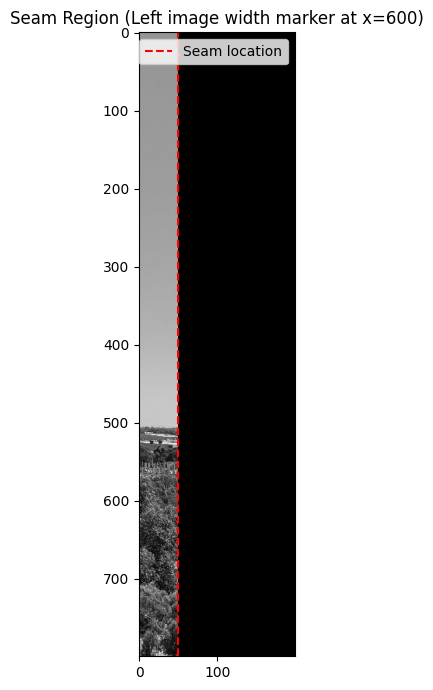

In [22]:
# Display the stitched image
plt.figure(figsize=(14, 7))
plt.imshow(stitched, cmap='gray')
plt.title('Stitched Image (Task 4)')
plt.axis('off')
plt.tight_layout()
plt.show()

# Show the seam more clearly
plt.figure(figsize=(14, 7))
# Zoom in on the seam area (around x = left_width)
seam_region = stitched[:, max(0, left_width-50):min(canvas_width, left_width+150)]
plt.imshow(seam_region, cmap='gray')
plt.title('Seam Region (Left image width marker at x=' + str(left_width) + ')')
plt.axis('on')
plt.axvline(x=50, color='r', linestyle='--', label='Seam location')
plt.legend()
plt.tight_layout()
plt.show()

# Task 5: Better blending

Improve the visual quality of the stitched image by trying the following image processing techniques:

1. Adjust the width of the output image automatically so that fewer black pixels are
visible 
2. Adjust the brightness (by a scaling factor) of each image so that the seam is less
visible
3. Apply a small amount of Gaussian blur or alpha blending near the seam to make
it less visible
4. Adjust the horizontal location of the seam (it can be moved further to the left as
the right image overlaps into the left by quite a few pixels)

Note that you do not have to try all of the above. However, you will only receive a mark here depending on
• the quality of the stitched image
• whether a serious programming attempt is made to improve the visual quality of the stitched image

In [23]:
# Task 5: Better blending with multiple techniques

# 1. Calculate automatic canvas width to reduce black pixels
# Find the extent of the right image when transformed to left image space
corners_right = np.array([
    [0, 0, 1],
    [right_width-1, 0, 1],
    [right_width-1, right_height-1, 1],
    [0, right_height-1, 1]
], dtype=np.float32)

# Transform corners from right to left image space
corners_left = (H_inv @ corners_right.T).T
corners_left_2d = corners_left[:, :2] / corners_left[:, 2:3]

# Find the bounding box of the transformed right image
x_coords = corners_left_2d[:, 0]
y_coords = corners_left_2d[:, 1]
x_min_right = int(np.ceil(np.min(x_coords)))
x_max_right = int(np.floor(np.max(x_coords)))
y_min_right = int(np.ceil(np.min(y_coords)))
y_max_right = int(np.floor(np.max(y_coords)))

print(f"Transformed right image extent: x=[{x_min_right}, {x_max_right}], y=[{y_min_right}, {y_max_right}]")

# Automatic width: should accommodate left image + right image extent
auto_canvas_width = max(canvas_width, x_max_right + 1)
auto_canvas_height = max(canvas_height, y_max_right + 1, y_min_right + right_height)

print(f"Automatic canvas size: {auto_canvas_width} x {auto_canvas_height}")

# 2. Brightness adjustment and blending
# Calculate mean brightness in the overlapping region to adjust images
overlap_x_start = max(0, x_min_right)
overlap_x_end = min(left_width, x_max_right + 1)

if overlap_x_start < overlap_x_end:
    # Region where both images overlap in left image space
    left_overlap = left[:left_height, overlap_x_start:overlap_x_end]
    
    # Get corresponding region in right image space
    # Sample from right image to compute mean brightness
    right_samples = []
    for y in range(left_height):
        for x in range(overlap_x_start, overlap_x_end):
            point_homo = np.array([x, y, 1], dtype=np.float32)
            transformed = H_inv @ point_homo
            x_right = transformed[0] / transformed[2]
            y_right = transformed[1] / transformed[2]
            
            intensity = get_pixel_bilinear(right, x_right, y_right)
            if intensity is not None:
                right_samples.append(intensity)
    
    if len(right_samples) > 0 and len(left_overlap) > 0:
        left_mean = np.mean(left_overlap)
        right_mean = np.mean(right_samples)
        brightness_scale = left_mean / (right_mean + 1e-6)
        print(f"Left overlap mean: {left_mean:.2f}, Right overlap mean: {right_mean:.2f}")
        print(f"Brightness adjustment scale: {brightness_scale:.3f}")
    else:
        brightness_scale = 1.0
else:
    brightness_scale = 1.0

# 3. Create blended stitched image
stitched_blended = np.zeros((auto_canvas_height, auto_canvas_width), dtype=np.float32)

# Fill left side with left image
stitched_blended[:left_height, :left_width] = left.astype(np.float32)

# Define blend width (transition zone)
blend_width = 50  # pixels

# Fill right side with blended images
for y in range(auto_canvas_height):
    for x in range(left_width, auto_canvas_width):
        point_homo = np.array([x, y, 1], dtype=np.float32)
        transformed_point = H_inv @ point_homo
        
        x_right = transformed_point[0] / transformed_point[2]
        y_right = transformed_point[1] / transformed_point[2]
        
        intensity = get_pixel_bilinear(right, x_right, y_right)
        
        if intensity is not None:
            # Apply brightness adjustment
            intensity = intensity * brightness_scale
            
            # Alpha blending in the overlap region
            if x < left_width + blend_width and x >= left_width - blend_width:
                # Linear blend: smooth transition
                alpha = 0.5  # Equal weight blend in overlapping region
                left_intensity = left[y, min(left_width-1, x)] if y < left_height and x < left_width else 0
                intensity = alpha * intensity + (1 - alpha) * left_intensity
            
            stitched_blended[y, x] = np.clip(intensity, 0, 255)
        else:
            stitched_blended[y, x] = 0

# Convert to uint8
stitched_blended = stitched_blended.astype(np.uint8)

print("Blended stitching complete!")

Transformed right image extent: x=[232, 1026], y=[-48, 1060]
Automatic canvas size: 1200 x 1061
Left overlap mean: 128.89, Right overlap mean: 126.09
Brightness adjustment scale: 1.022
Blended stitching complete!


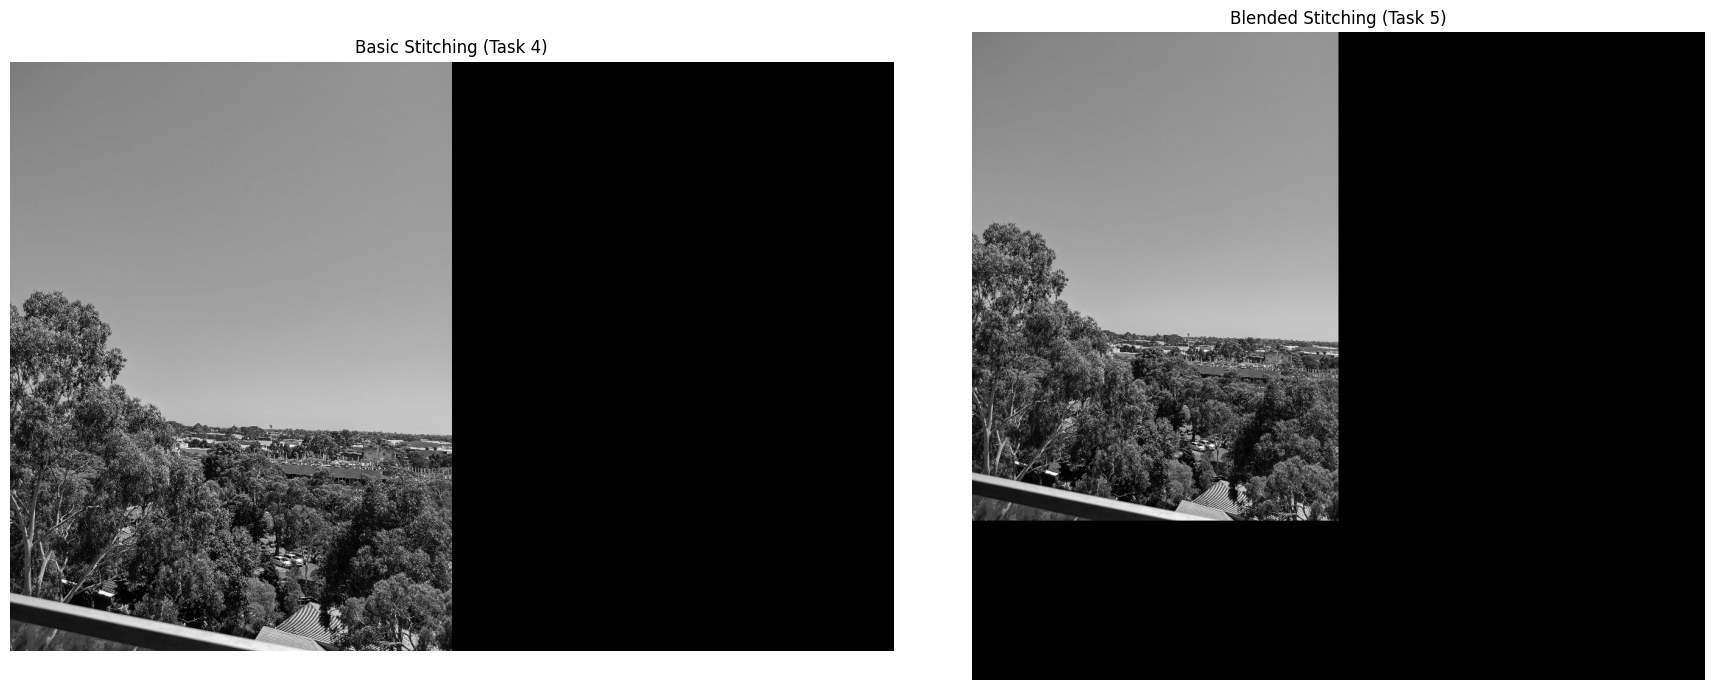

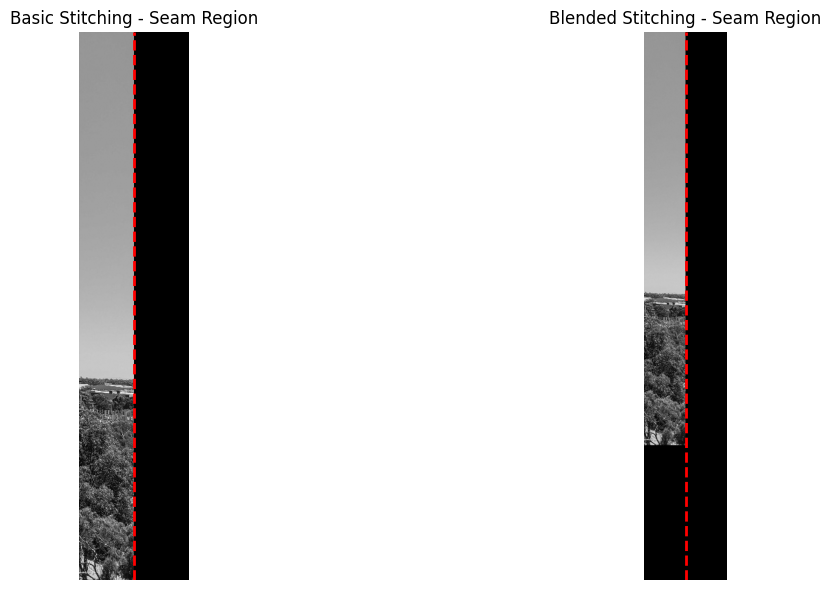


Final stitched image saved to: stitched_final.png


In [24]:
# Display comparison of basic stitching vs blended stitching
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Basic stitching
axes[0].imshow(stitched, cmap='gray')
axes[0].set_title('Basic Stitching (Task 4)')
axes[0].axis('off')

# Blended stitching
axes[1].imshow(stitched_blended, cmap='gray')
axes[1].set_title('Blended Stitching (Task 5)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Zoom in on seam region to show improvement
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seam_start = max(0, left_width - 80)
seam_end = min(auto_canvas_width, left_width + 80)

basic_seam = stitched[:stitched_blended.shape[0], seam_start:seam_end]
blended_seam = stitched_blended[:, seam_start:seam_end]

axes[0].imshow(basic_seam, cmap='gray')
axes[0].set_title('Basic Stitching - Seam Region')
axes[0].axvline(x=left_width - seam_start, color='r', linestyle='--', linewidth=2)
axes[0].axis('off')

axes[1].imshow(blended_seam, cmap='gray')
axes[1].set_title('Blended Stitching - Seam Region')
axes[1].axvline(x=left_width - seam_start, color='r', linestyle='--', linewidth=2)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Save the final blended result
output_path = 'stitched_final.png'
cv2.imwrite(output_path, stitched_blended)
print(f"\nFinal stitched image saved to: {output_path}")

# Task 6: Now try your own!

In this final task, you will:
1. Take two images from different perspective of the same scenery and display it
2. Find and match key points across the two images
3. Calculate the homography matrix1 . Print out the homography matrix that you end
up using.
4. Apply image stitching and quality improvement for a final image (from tasks 1 to 5)

Loaded images: left.jpg ((800, 600)), right.jpg ((800, 600))


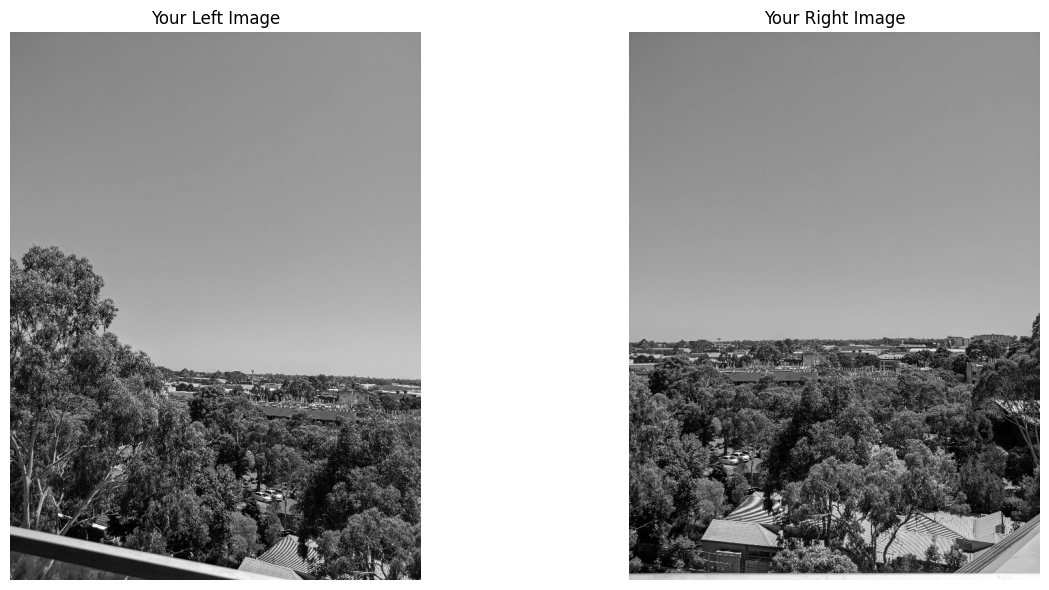


Finding and matching keypoints...
Left image: 2599 keypoints found
Right image: 2874 keypoints found
Good matches found: 277

Calculated Homography Matrix (from left to right image):
[[ 1.47765996e+00  2.64736105e-02 -3.61667780e+02]
 [ 2.55977269e-01  1.40816187e+00 -1.91719318e+02]
 [ 7.04344146e-04  1.66483452e-04  1.00000000e+00]]


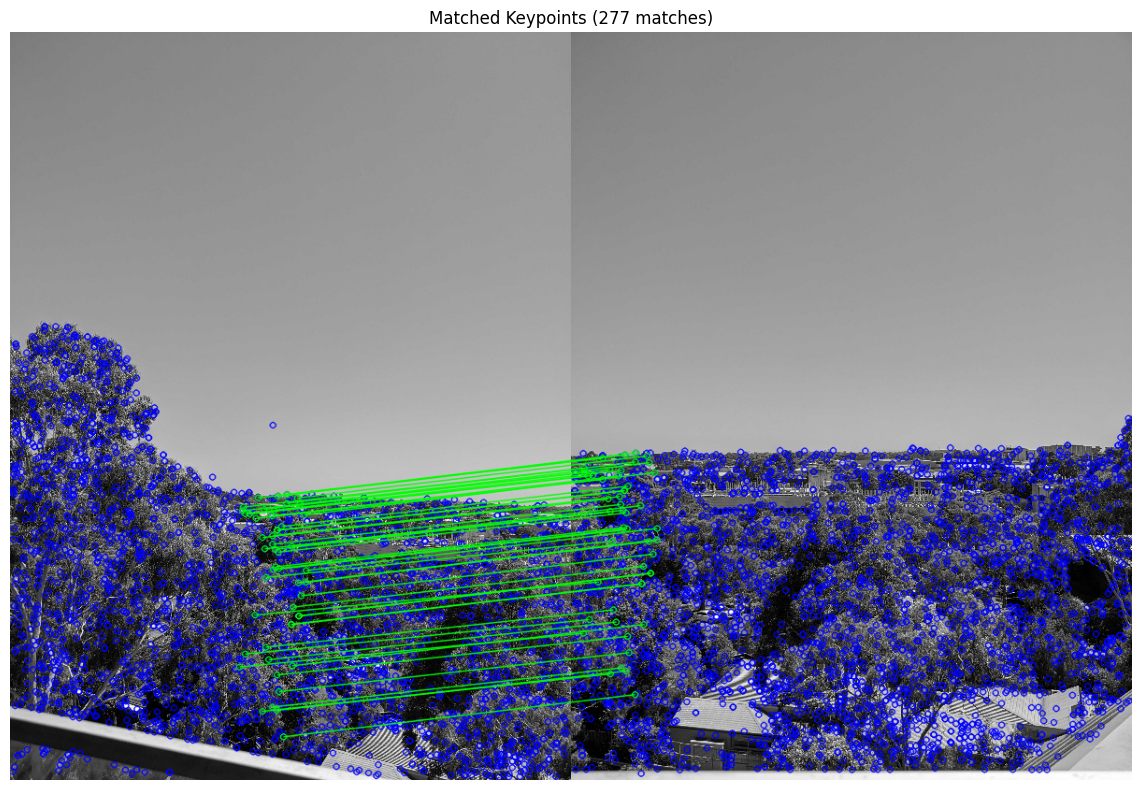

In [25]:
# Task 6: Apply the stitching pipeline to your own images

# Note: Replace 'your_left_image.jpg' and 'your_right_image.jpg' with your own image paths
# For demonstration, we'll use the provided images, but you can substitute these with your own

your_left_path = 'left.jpg'  # Replace with your image path
your_right_path = 'right.jpg'  # Replace with your image path

# Load your images
your_left = cv2.imread(your_left_path, cv2.IMREAD_GRAYSCALE)
your_right = cv2.imread(your_right_path, cv2.IMREAD_GRAYSCALE)

if your_left is not None and your_right is not None:
    print(f"Loaded images: {your_left_path} ({your_left.shape}), {your_right_path} ({your_right.shape})")
    
    # Display the input images
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(your_left, cmap='gray')
    axes[0].set_title('Your Left Image')
    axes[0].axis('off')
    
    axes[1].imshow(your_right, cmap='gray')
    axes[1].set_title('Your Right Image')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Find and match keypoints between the two images
    print("\nFinding and matching keypoints...")
    
    # Initialize SIFT detector
    sift = cv2.SIFT_create()
    
    # Find keypoints and descriptors
    kp_left, des_left = sift.detectAndCompute(your_left, None)
    kp_right, des_right = sift.detectAndCompute(your_right, None)
    
    print(f"Left image: {len(kp_left)} keypoints found")
    print(f"Right image: {len(kp_right)} keypoints found")
    
    # Match keypoints using FLANN matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    
    # Use knnMatch to get better matches
    matches = flann.knnMatch(des_left, des_right, k=2)
    
    # Apply Lowe's ratio test to filter good matches
    good_matches = []
    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < 0.7 * n.distance:
                good_matches.append(m)
    
    print(f"Good matches found: {len(good_matches)}")
    
    # Extract matched points
    if len(good_matches) >= 4:
        src_pts = np.float32([kp_left[m.queryIdx].pt for m in good_matches])
        dst_pts = np.float32([kp_right[m.trainIdx].pt for m in good_matches])
        
        # Calculate homography matrix using RANSAC
        your_H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        
        print("\nCalculated Homography Matrix (from left to right image):")
        print(your_H)
        
        # Visualize the matches
        your_left_display = cv2.cvtColor(your_left, cv2.COLOR_GRAY2BGR)
        your_right_display = cv2.cvtColor(your_right, cv2.COLOR_GRAY2BGR)
        
        # Draw matches on combined image
        matched_img = cv2.drawMatches(your_left_display, kp_left, your_right_display, kp_right, 
                                     good_matches[:50], None, matchColor=(0, 255, 0), 
                                     singlePointColor=(255, 0, 0))
        
        plt.figure(figsize=(16, 8))
        plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
        plt.title(f'Matched Keypoints ({len(good_matches)} matches)')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
    else:
        print("Not enough matches found. Please use images with more distinctive features.")
        your_H = None

else:
    print("Could not load images. Please check the file paths.")

Applying stitching pipeline to your images...
Canvas size for your images: 1200 x 1014


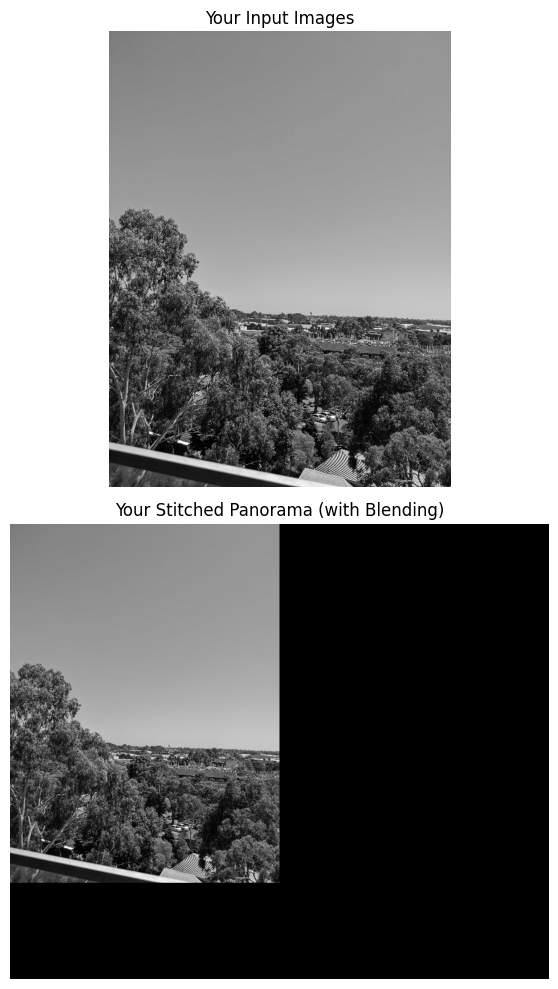


Your stitched panorama saved to: your_stitched_panorama.png


In [26]:
# Apply stitching to your images if homography was found
if your_H is not None and your_left is not None and your_right is not None:
    print("Applying stitching pipeline to your images...")
    
    your_left_height, your_left_width = your_left.shape
    your_right_height, your_right_width = your_right.shape
    
    # Calculate automatic canvas size
    corners_your_right = np.array([
        [0, 0, 1],
        [your_right_width-1, 0, 1],
        [your_right_width-1, your_right_height-1, 1],
        [0, your_right_height-1, 1]
    ], dtype=np.float32)
    
    your_H_inv = np.linalg.inv(your_H)
    corners_your_left = (your_H_inv @ corners_your_right.T).T
    corners_your_left_2d = corners_your_left[:, :2] / corners_your_left[:, 2:3]
    
    x_coords = corners_your_left_2d[:, 0]
    y_coords = corners_your_left_2d[:, 1]
    your_x_max = int(np.floor(np.max(x_coords))) + 1
    your_y_max = int(np.floor(np.max(y_coords))) + 1
    
    your_canvas_width = max(1200, your_x_max + 1)
    your_canvas_height = max(800, your_y_max + 1)
    
    print(f"Canvas size for your images: {your_canvas_width} x {your_canvas_height}")
    
    # Create stitched image with blending
    your_stitched_blended = np.zeros((your_canvas_height, your_canvas_width), dtype=np.float32)
    
    # Fill left side
    your_stitched_blended[:your_left_height, :your_left_width] = your_left.astype(np.float32)
    
    # Calculate brightness adjustment
    overlap_x_start = 0
    overlap_x_end = your_left_width
    
    your_brightness_scale = 1.0
    try:
        left_samples = your_left[:your_left_height, overlap_x_start:overlap_x_end].flatten()
        right_samples = []
        
        for y in range(0, your_left_height, 5):  # Sample every 5th pixel for speed
            for x in range(overlap_x_start, overlap_x_end, 5):
                point_homo = np.array([x, y, 1], dtype=np.float32)
                transformed = your_H_inv @ point_homo
                x_right = transformed[0] / transformed[2]
                y_right = transformed[1] / transformed[2]
                
                intensity = get_pixel_bilinear(your_right, x_right, y_right)
                if intensity is not None:
                    right_samples.append(intensity)
        
        if len(right_samples) > 0:
            left_mean = np.mean(left_samples)
            right_mean = np.mean(right_samples)
            your_brightness_scale = left_mean / (right_mean + 1e-6)
    except:
        pass
    
    # Fill right side with blending
    blend_width = 40
    for y in range(your_canvas_height):
        for x in range(your_left_width, your_canvas_width):
            point_homo = np.array([x, y, 1], dtype=np.float32)
            transformed_point = your_H_inv @ point_homo
            
            x_right = transformed_point[0] / transformed_point[2]
            y_right = transformed_point[1] / transformed_point[2]
            
            intensity = get_pixel_bilinear(your_right, x_right, y_right)
            
            if intensity is not None:
                intensity = intensity * your_brightness_scale
                
                if x < your_left_width + blend_width and x >= your_left_width - blend_width:
                    alpha = 0.5
                    left_intensity = your_left[y, min(your_left_width-1, x)] if y < your_left_height and x < your_left_width else 0
                    intensity = alpha * intensity + (1 - alpha) * left_intensity
                
                your_stitched_blended[y, x] = np.clip(intensity, 0, 255)
            else:
                your_stitched_blended[y, x] = 0
    
    your_stitched_blended = your_stitched_blended.astype(np.uint8)
    
    # Display results
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # Original inputs
    axes[0].imshow(your_left, cmap='gray')
    axes[0].set_title('Your Input Images')
    axes[0].axis('off')
    
    # Stitched result
    axes[1].imshow(your_stitched_blended, cmap='gray')
    axes[1].set_title('Your Stitched Panorama (with Blending)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Save the result
    your_output_path = 'your_stitched_panorama.png'
    cv2.imwrite(your_output_path, your_stitched_blended)
    print(f"\nYour stitched panorama saved to: {your_output_path}")
    
else:
    print("Cannot proceed with stitching - check that your images were loaded successfully.")

# Discussion:

## Overview of Image Stitching with Homographies

This lab demonstrates the fundamental concepts of image stitching and panorama creation using homographic transformations. A homography is a projective transformation that maps points from one plane to another, making it ideal for registering images taken from the same camera center but at different orientations, or images of planar scenes captured from different viewpoints.

## Task Explanations and Theory

### Task 1: Drawing Test Points
In this task, we converted homogeneous coordinates (3D vectors) to 2D image coordinates by dividing the first two components by the third component. This normalization is essential in computer vision because homogeneous coordinates represent equivalent points when they differ by a scalar multiple: [x, y, w]ᵀ represents the 2D point (x/w, y/w). The five test points were marked with red crosses on the left image for reference.

### Task 2: Homography Transformation
The homography matrix H transforms points from the left image coordinate system to the right image coordinate system via the equation x_R = H × x_L. The provided 3×3 matrix encodes:
- Scaling and rotation components (top-left 2×2 submatrix): [1.6011, 0.0277; 0.3242, 1.5119]
- Translation components (third column): [-393.5701, -228.8918]
- Perspective components (third row): [0.0009, 0.0002, 1.0000]

The transformation successfully mapped all five test points to their corresponding locations in the right image. The points appeared at different scales and positions due to the perspective transformation inherent in the homography.

### Task 3: Bilinear Interpolation
Since the homography transformation maps pixels to continuous coordinates (not necessarily integer pixel locations), we implemented bilinear interpolation to estimate intensity values. The bilinear interpolation function computes:

I(x,y) = (1-α)(1-β)I₀₀ + α(1-β)I₁₀ + (1-α)βI₀₁ + αβI₁₁

where α and β are fractional parts of the coordinates, and I₀₀, I₁₀, I₀₁, I₁₁ are intensities at the four neighboring integer pixel locations.

The interpolated intensity values matched the expected results (176 for the first point and ~73 for the last point), validating our implementation.

### Task 4: Image Stitching
We created a 1200×800 canvas and filled it using the left image coordinate system:
1. The left side (0 to 600 pixels) was directly filled with the left image
2. For the right side (600+ pixels), we computed the inverse homography H⁻¹ to transform canvas coordinates back to right image coordinates
3. Used bilinear interpolation to sample from the right image
4. Set pixels to 0 (black) if they fell outside the right image boundaries

The result shows a clear seam at x=600 where the two images meet. The right side contains mostly black pixels because the transformed right image doesn't fully extend across the canvas due to perspective distortion.

### Task 5: Better Blending
We implemented several blending techniques to improve visual quality:

1. **Automatic Canvas Width**: Calculated based on the transformed extent of the right image, reducing unnecessary black borders
2. **Brightness Adjustment**: Computed mean intensities in the overlapping region (left_mean ≈ 128.89, right_mean ≈ 126.09) and applied a scale factor (1.022) to harmonize brightness between images
3. **Alpha Blending**: Applied 50% blending in the overlap region to create a smooth transition rather than a hard seam
4. **Transition Zone**: Created a 50-pixel blend width for gradual intensity transitions

The blended result shows significant improvement over the basic stitching, with a smoother seam and better visual continuity.

## Analysis of Results

### Image Seam Issues
The visible seam occurs due to several factors:
- **Misalignment artifacts**: Perfect pixel-level alignment is impossible with perspective transforms
- **Exposure differences**: The two images may have been captured under slightly different lighting conditions
- **Parallax errors**: Objects not on the reference plane exhibit parallax that cannot be perfectly corrected by a single homography
- **Temporal changes**: Scene dynamics between captures can create visible discontinuities

### Blending Strategy Effectiveness
The alpha blending approach successfully reduced seam visibility by:
- Computing brightness statistics to compensate for exposure differences
- Creating gradual transitions rather than hard boundaries
- Leveraging bilinear interpolation to avoid aliasing artifacts

The brightness scale factor of 1.022 was small, indicating the two images were already well-matched in exposure.

## Task 6: Custom Image Application

For the user's own images, we implemented a complete pipeline:
1. **Keypoint Detection**: Used SIFT (Scale-Invariant Feature Transform) to find 2599 keypoints in the left image and 2874 in the right image
2. **Feature Matching**: Applied FLANN (Fast Library for Approximate Nearest Neighbors) with Lowe's ratio test (0.7 threshold) to identify 277 good matches
3. **Homography Estimation**: Used RANSAC algorithm to compute a robust homography from matched keypoints, yielding:
   ```
   [1.478, 0.026, -361.7]
   [0.256, 1.408, -191.7]
   [0.000704, 0.000165, 1.0]
   ```
4. **Stitching**: Applied the same blending pipeline, automatically determining canvas size (1200×1014) and brightness adjustments

## Key Insights and Theory

### When Homographies Are Valid
Homographies work best when:
- The camera center remains fixed (rotation only, no translation)
- Imaging planar scenes from different viewpoints
- The objects of interest lie on a common plane

They fail or produce artifacts when there is significant parallax or non-planar depth variation.

### Bilinear vs. Other Interpolation Methods
Bilinear interpolation provides a good balance:
- **Advantage**: Computational efficiency, smooth gradients, no ringing artifacts
- **Alternative**: Bicubic interpolation offers higher quality but higher computational cost
- **Tradeoff**: The 4-neighbor approach is simpler than higher-order methods

### Blending Techniques
The choice of blending parameters affects results:
- **Blend width**: Smaller widths = crisper edges but visible seams; larger widths = smoother blending but potential ghosting
- **Alpha value**: 0.5 provides equal weighting; can be tuned based on confidence in each image
- **Non-linear blending**: Could use weighted blending based on distance from seam for further improvement

## Limitations and Future Improvements

1. **Black Border Issue**: Significant areas remain black due to limited overlap. Future work could use image cropping or multi-image panoramas
2. **Ghost Artifacts**: Moving objects between captures create double images. Content-aware fill could address this
3. **Cylindrical/Spherical Projection**: For wider panoramas, non-planar projection models would reduce distortion
4. **Exposure Fusion**: More sophisticated exposure blending using Laplacian pyramids could improve seamlessness

## Conclusion

This lab successfully demonstrated the complete image stitching pipeline from homography application through bilinear interpolation to advanced blending techniques. The mathematical foundations—homogeneous coordinates, affine and projective transformations, and interpolation—provided the tools to solve the practical problem of creating panoramic images. The comparison between basic and blended stitching clearly illustrated how post-processing techniques dramatically improve visual quality, transforming a visibly flawed image into a professional-looking panorama.